# BTCUSDC Order-Flow Study: Robustness And Comparison

This notebook checks whether the raw-trade findings are stable under clipping, price choice, sample length, and the old 1-second bar view.


## What This Notebook Tests

- keep the paper-style raw-trade object fixed, but vary the measurement choice around it
- compare raw vs clipped quantities
- compare midprice returns vs trade-price returns
- compare one-day and multi-day summaries
- compare the old 1-second bar baseline with the raw-trade view

The horizon convention stays the same as in notebook 03: `T` is a number of trades, not clock time.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
def find_backtester_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stats.features.book import resample_book
from stats.features.trades import trades_to_bars
from stats.io import load_day
from stats.tables import get_or_build_top_of_book_table, get_or_build_trades_table

DATA_ROOT = PROJECT_ROOT.parent / "exchange-data-recorder" / "data"
SYMBOL = "BTCUSDC"
REFERENCE_DAY = "20260223"
DAY_LIST = ["20260222", "20260223", "20260224", "20260225", "20260226", "20260227", "20260228", "20260301"]


In [3]:
def find_day_dir(day: str) -> Path:
    candidates = [
        DATA_ROOT / "binance" / SYMBOL / day,
        DATA_ROOT / SYMBOL / day,
    ]
    for candidate in candidates:
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate day directory for {SYMBOL}/{day}")


def load_day_tables(day: str):
    dataset = load_day(find_day_dir(day))
    trades = get_or_build_trades_table(dataset)
    top = get_or_build_top_of_book_table(dataset, on_gap="skip-segment")
    return trades, top


def rolling_window_sum(x: np.ndarray, T: int) -> np.ndarray:
    if T <= 0:
        raise ValueError("T must be positive")
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < T:
        return out
    csum = np.cumsum(np.insert(x, 0, 0.0))
    out[T - 1 :] = csum[T:] - csum[:-T]
    return out


def build_imbalance_series(sign: np.ndarray, qty: np.ndarray, T: int, a: float) -> np.ndarray:
    weighted = sign * np.power(qty, a)
    return rolling_window_sum(weighted, T)


def make_trade_frame(trades_df: pd.DataFrame, top_df: pd.DataFrame | None = None, *, price_source: str = "mid") -> pd.DataFrame:
    frame = trades_df[["ts", "qty", "aggr_sign", "price"]].copy()
    frame = frame[np.isfinite(frame["qty"]) & np.isfinite(frame["aggr_sign"])].copy()
    frame = frame.sort_values("ts").reset_index(drop=True)

    if price_source == "mid":
        if top_df is None:
            raise ValueError("top_df is required when price_source='mid'")
        book_mid = top_df[["ts", "mid"]].dropna().sort_values("ts").rename(columns={"mid": "price_ref"})
        frame = pd.merge_asof(frame, book_mid, on="ts", direction="backward")
        frame = frame.dropna(subset=["price_ref"]).reset_index(drop=True)
    elif price_source == "trade":
        frame = frame.rename(columns={"price": "price_ref"})
    else:
        raise ValueError("price_source must be 'mid' or 'trade'")

    frame["log_price_ref"] = np.log(frame["price_ref"])
    frame["trade_idx"] = np.arange(len(frame))
    return frame


def build_cov_corr_frame(trade_frame: pd.DataFrame, T: int, a: float) -> pd.DataFrame:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    log_price = trade_frame["log_price_ref"].to_numpy(dtype=float)

    imbalance = build_imbalance_series(sign, qty, T=T, a=a)
    delta = np.full(len(log_price), np.nan, dtype=float)
    if len(log_price) > T:
        delta[:-T] = log_price[T:] - log_price[:-T]

    return pd.DataFrame({"I": imbalance, "delta": delta}).dropna().copy()


def summarize_cov_corr(frame: pd.DataFrame) -> pd.Series:
    x = frame["I"].to_numpy(dtype=float)
    y = frame["delta"].to_numpy(dtype=float)
    if len(x) == 0:
        return pd.Series({"cov": np.nan, "corr": np.nan, "n": 0})
    cov = float(np.mean((x - x.mean()) * (y - y.mean())))
    corr = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan
    return pd.Series({"cov": cov, "corr": corr, "n": len(x)})


def clip_qty(qty: pd.Series, cap: float | None) -> pd.Series:
    if cap is None:
        return qty.copy()
    return np.minimum(qty.to_numpy(dtype=float), float(cap))


def run_length_stats(sign: pd.Series) -> pd.Series:
    values = sign.to_numpy(dtype=float)
    if len(values) == 0:
        return pd.Series({"mean_run_length": np.nan, "median_run_length": np.nan, "p90_run_length": np.nan, "n_runs": 0})
    change_idx = np.flatnonzero(np.diff(values) != 0)
    bounds = np.r_[0, change_idx + 1, len(values)]
    run_lengths = np.diff(bounds)
    return pd.Series({
        "mean_run_length": float(run_lengths.mean()),
        "median_run_length": float(np.median(run_lengths)),
        "p90_run_length": float(np.quantile(run_lengths, 0.9)),
        "n_runs": int(len(run_lengths)),
    })


def sign_autocorr(sign: pd.Series, lags: list[int]) -> pd.Series:
    values = sign.to_numpy(dtype=float)
    out = {}
    for lag in lags:
        if lag <= 0 or len(values) <= lag:
            out[f"acf_{lag}"] = np.nan
            continue
        x = values[:-lag]
        y = values[lag:]
        if len(x) < 2:
            out[f"acf_{lag}"] = np.nan
        else:
            out[f"acf_{lag}"] = float(np.corrcoef(x, y)[0, 1])
    return pd.Series(out)


def make_1s_baseline(trades_df: pd.DataFrame, top_df: pd.DataFrame) -> pd.DataFrame:
    bars = trades_to_bars(trades_df, grid_freq="1s", time_col_ms="recv_time_ms")
    book_1s = resample_book(top_df, grid_freq="1s")
    frame = bars.join(book_1s[["mid"]], how="inner")
    frame["log_mid"] = np.log(frame["mid"])
    frame["fwd_ret_1s"] = frame["log_mid"].shift(-1) - frame["log_mid"]
    return frame.dropna(subset=["signed_qty", "fwd_ret_1s"]).copy()


## Reference Day Summary

We start with `BTCUSDC / 20260223` because it is the same day used in notebooks 01 to 03.


In [4]:
trades_ref, top_ref = load_day_tables(REFERENCE_DAY)
trade_frame_mid = make_trade_frame(trades_ref, top_ref, price_source="mid")
trade_frame_trade = make_trade_frame(trades_ref, price_source="trade")

paper_clip_qty = 0.01 * float(trades_ref["qty"].sum())
qty_q995 = float(trades_ref["qty"].quantile(0.995))
qty_q99 = float(trades_ref["qty"].quantile(0.99))

reference_summary = pd.Series({
    "day": REFERENCE_DAY,
    "trade_rows": len(trades_ref),
    "book_rows": len(top_ref),
    "total_qty": float(trades_ref["qty"].sum()),
    "paper_clip_qty": paper_clip_qty,
    "share_above_paper_clip": float((trades_ref["qty"] > paper_clip_qty).mean()),
    "qty_q99": qty_q99,
    "qty_q995": qty_q995,
    "mean_run_length": float(run_length_stats(trades_ref["aggr_sign"])["mean_run_length"]),
    "acf_10": float(sign_autocorr(trades_ref["aggr_sign"], [10])["acf_10"]),
    "acf_100": float(sign_autocorr(trades_ref["aggr_sign"], [100])["acf_100"]),
})

display(reference_summary.to_frame("value"))


,value
day,20260223
trade_rows,868008
book_rows,722893
total_qty,7548.97427
paper_clip_qty,75.489743
share_above_paper_clip,0.0
qty_q99,0.125709
qty_q995,0.15752
mean_run_length,17.352872
acf_10,0.606149


## Clipping Robustness

The paper-style clip is retained for methodology, but on this day it is effectively inactive. To see whether the conclusion depends on that, we also add a tighter stress clip at the 99.5th percentile.


In [5]:
a_list = [0.0, 0.3, 1.0]
T_list = [10, 50, 100]
clip_specs = {
    "raw": None,
    "paper_clip": paper_clip_qty,
    "stress_q995": qty_q995,
}

clip_rows = []
for clip_name, cap in clip_specs.items():
    qty_used = clip_qty(trade_frame_mid["qty"], cap)
    frame = trade_frame_mid.copy()
    frame["qty_used"] = qty_used
    for a in a_list:
        for T in T_list:
            temp = frame[["ts", "qty_used", "aggr_sign", "log_price_ref"]].rename(columns={"qty_used": "qty"})
            summary = summarize_cov_corr(build_cov_corr_frame(temp, T=T, a=a))
            clip_rows.append({
                "clip": clip_name,
                "a": a,
                "T": T,
                "cov": float(summary["cov"]),
                "corr": float(summary["corr"]),
                "n": int(summary["n"]),
            })

clip_df = pd.DataFrame(clip_rows)
display(clip_df)

clip_corr = clip_df.pivot_table(index=["a", "T"], columns="clip", values="corr")
display(clip_corr)


,clip,a,T,cov,corr,n
0,raw,0.0,10,0.000297,0.394256,867989
1,raw,0.0,50,0.002163,0.278185,867909
2,raw,0.0,100,0.003551,0.175621,867809
3,raw,0.3,10,0.000039,0.372026,867989
4,raw,0.3,50,0.000277,0.290943,867909
5,raw,0.3,100,0.000414,0.176342,867809
6,raw,1.0,10,0.000003,0.168124,867989
7,raw,1.0,50,0.000024,0.174274,867909
8,raw,1.0,100,0.000034,0.107067,867809
9,paper_clip,0.0,10,0.000297,0.394256,867989


clip     paper_clip       raw  stress_q995
a   T                                     
0.0 10     0.394256  0.394256     0.394256
    50     0.278185  0.278185     0.278185
    100    0.175621  0.175621     0.175621
0.3 10     0.372026  0.372026     0.374578
    50     0.290943  0.290943     0.292095
    100    0.176342  0.176342     0.176886
1.0 10     0.168124  0.168124     0.246817
    50     0.174274  0.174274     0.227897
    100    0.107067  0.107067     0.129783

## Midprice Versus Trade-Price Returns

The raw-trade signal can be paired with either a book-derived midprice or the trade print itself. Midprice is the cleaner benchmark; trade price is the noisier comparison.


,price_source,a,T,cov,corr
0,mid,0.0,10,0.000297,0.394256
1,mid,0.0,20,0.000812,0.389714
2,mid,0.0,50,0.002163,0.278185
3,mid,0.0,100,0.003551,0.175621
4,mid,0.0,150,0.004454,0.128201
5,mid,0.0,200,0.005368,0.106159
6,mid,0.2,10,0.000071,0.396414
7,mid,0.2,20,0.000195,0.406353
8,mid,0.2,50,0.000505,0.295954
9,mid,0.2,100,0.000782,0.181709


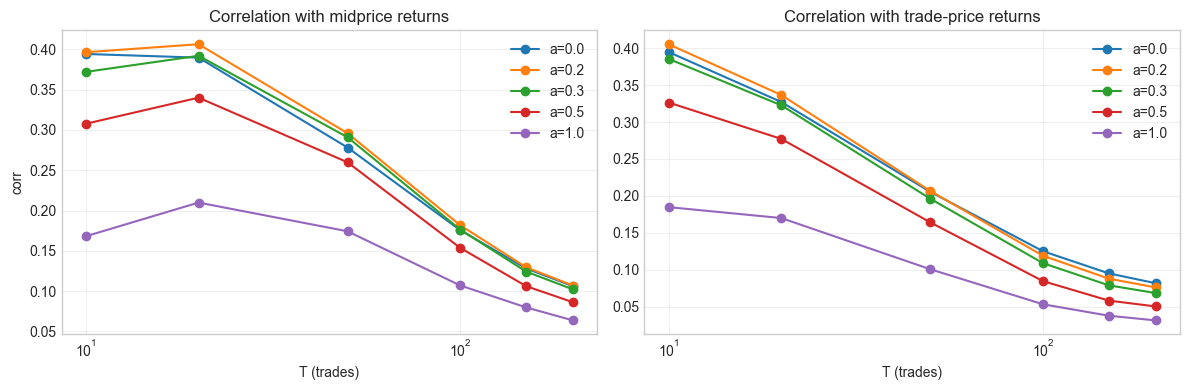

In [12]:
price_rows = []
for price_source, frame in [("mid", trade_frame_mid), ("trade", trade_frame_trade)]:
    for a in [0.0, 0.2, 0.3, 0.5, 1.0]:
        for T in [10, 20, 50, 100, 150, 200]:
            summary = summarize_cov_corr(build_cov_corr_frame(frame, T=T, a=a))
            price_rows.append({
                "price_source": price_source,
                "a": a,
                "T": T,
                "cov": float(summary["cov"]),
                "corr": float(summary["corr"]),
            })

price_df = pd.DataFrame(price_rows)
display(price_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for a in [0.0, 0.2, 0.3, 0.5, 1.0]:
    tmp = price_df[(price_df["a"] == a) & (price_df["price_source"] == "mid")].sort_values("T")
    axes[0].plot(tmp["T"], tmp["corr"], marker="o", label=f"a={a}")
    tmp = price_df[(price_df["a"] == a) & (price_df["price_source"] == "trade")].sort_values("T")
    axes[1].plot(tmp["T"], tmp["corr"], marker="o", label=f"a={a}")

axes[0].set_xscale("log")
axes[0].set_title("Correlation with midprice returns")
axes[0].set_xlabel("T (trades)")
axes[0].set_ylabel("corr")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xscale("log")
axes[1].set_title("Correlation with trade-price returns")
axes[1].set_xlabel("T (trades)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## One-Day Versus Multi-Day Stability

This section checks whether the same signal survives beyond the reference day. The goal is not to build a full panel model, only to see whether the sign and rough magnitude are stable across nearby days.


,day,trade_rows,total_qty,paper_clip_qty,share_above_paper_clip,mean_run_length,median_run_length,acf_10,acf_100,corr_mid_T10_a03,corr_mid_T100_a03,corr_mid_T10_a10,corr_mid_T100_a10
0,20260222,72092,1102.61819,11.026182,0.000028,11.812551,3.0,0.509195,0.030592,0.422042,0.192641,0.137152,0.137884
1,20260223,868008,7548.97427,75.489743,0.000000,17.352872,5.0,0.606149,0.179762,0.372026,0.176342,0.168124,0.107067
2,20260224,914206,6699.51508,66.995151,0.000000,20.792531,7.0,0.639886,0.141588,0.384608,0.196747,0.122935,0.090636
3,20260225,845228,7690.94342,76.909434,0.000000,14.889950,5.0,0.556944,0.139390,0.344269,0.167343,0.143710,0.109902
4,20260226,655230,5916.12499,59.161250,0.000000,17.544381,6.0,0.574160,0.138292,0.354394,0.159840,0.163824,0.117377
5,20260227,508380,5868.59347,58.685935,0.000000,13.686364,5.0,0.483144,0.098673,0.317491,0.138136,0.113443,0.078755
6,20260228,682674,6716.79054,67.167905,0.000000,13.835556,5.0,0.496293,0.086758,0.364746,0.170136,0.141292,0.119916
7,20260301,442284,5075.14476,50.751448,0.000000,11.564492,4.0,0.448302,0.076895,0.363769,0.160894,0.188849,0.109921


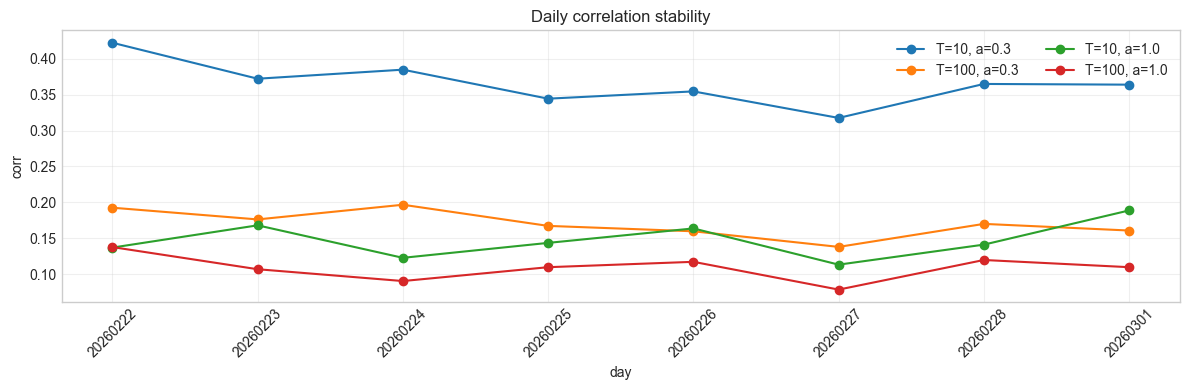

In [7]:
daily_rows = []
for day in DAY_LIST:
    trades_day, top_day = load_day_tables(day)
    frame_mid = make_trade_frame(trades_day, top_day, price_source="mid")
    run_stats = run_length_stats(trades_day["aggr_sign"])
    acf_stats = sign_autocorr(trades_day["aggr_sign"], [10, 100])
    daily_rows.append({
        "day": day,
        "trade_rows": len(trades_day),
        "total_qty": float(trades_day["qty"].sum()),
        "paper_clip_qty": float(0.01 * trades_day["qty"].sum()),
        "share_above_paper_clip": float((trades_day["qty"] > 0.01 * trades_day["qty"].sum()).mean()),
        "mean_run_length": float(run_stats["mean_run_length"]),
        "median_run_length": float(run_stats["median_run_length"]),
        "acf_10": float(acf_stats["acf_10"]),
        "acf_100": float(acf_stats["acf_100"]),
        "corr_mid_T10_a03": float(summarize_cov_corr(build_cov_corr_frame(frame_mid, T=10, a=0.3))["corr"]),
        "corr_mid_T100_a03": float(summarize_cov_corr(build_cov_corr_frame(frame_mid, T=100, a=0.3))["corr"]),
        "corr_mid_T10_a10": float(summarize_cov_corr(build_cov_corr_frame(frame_mid, T=10, a=1.0))["corr"]),
        "corr_mid_T100_a10": float(summarize_cov_corr(build_cov_corr_frame(frame_mid, T=100, a=1.0))["corr"]),
    })

daily_df = pd.DataFrame(daily_rows)
display(daily_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_df["day"], daily_df["corr_mid_T10_a03"], marker="o", label="T=10, a=0.3")
ax.plot(daily_df["day"], daily_df["corr_mid_T100_a03"], marker="o", label="T=100, a=0.3")
ax.plot(daily_df["day"], daily_df["corr_mid_T10_a10"], marker="o", label="T=10, a=1.0")
ax.plot(daily_df["day"], daily_df["corr_mid_T100_a10"], marker="o", label="T=100, a=1.0")
ax.set_title("Daily correlation stability")
ax.set_xlabel("day")
ax.set_ylabel("corr")
ax.tick_params(axis='x', rotation=45)
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Old 1-Second Bar Baseline

This comparison is intentionally secondary. It shows how much signal survives after collapsing the tape to clock time.


,value
bar_rows,80095.000000
trade_rows,868008.000000
mean_signed_qty,-0.000126
corr_tfi_qty_fwd_ret_1s,NaN
corr_signed_qty_fwd_ret_1s,0.037867
raw_trade_corr_T10_a0,0.394256
raw_trade_corr_T10_a03,0.372026


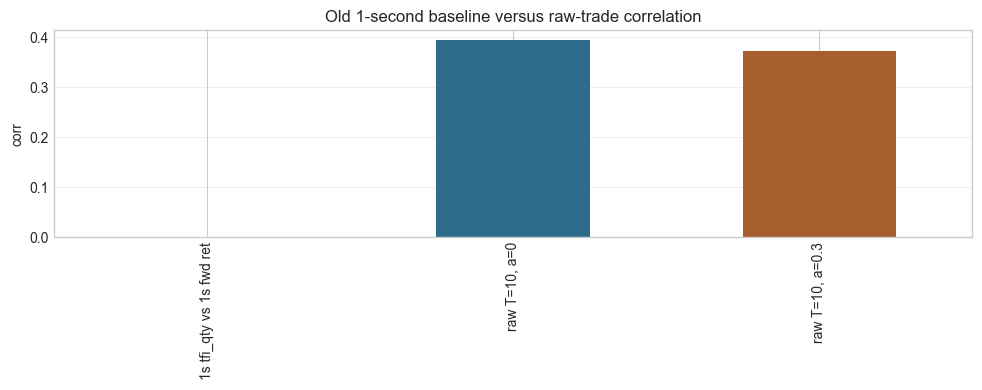

In [8]:
bars_1s = make_1s_baseline(trades_ref, top_ref)
bar_summary = pd.Series({
    "bar_rows": len(bars_1s),
    "trade_rows": len(trades_ref),
    "mean_signed_qty": float(bars_1s["signed_qty"].mean()),
    "corr_tfi_qty_fwd_ret_1s": float(np.corrcoef(bars_1s["tfi_qty"], bars_1s["fwd_ret_1s"])[0, 1]),
    "corr_signed_qty_fwd_ret_1s": float(np.corrcoef(bars_1s["signed_qty"], bars_1s["fwd_ret_1s"])[0, 1]),
    "raw_trade_corr_T10_a0": float(summarize_cov_corr(build_cov_corr_frame(trade_frame_mid, T=10, a=0.0))["corr"]),
    "raw_trade_corr_T10_a03": float(summarize_cov_corr(build_cov_corr_frame(trade_frame_mid, T=10, a=0.3))["corr"]),
})
display(bar_summary.to_frame("value"))

fig, ax = plt.subplots(figsize=(10, 4))
comparison = pd.Series({
    "1s tfi_qty vs 1s fwd ret": bar_summary["corr_tfi_qty_fwd_ret_1s"],
    "raw T=10, a=0": bar_summary["raw_trade_corr_T10_a0"],
    "raw T=10, a=0.3": bar_summary["raw_trade_corr_T10_a03"],
})
comparison.plot(kind="bar", ax=ax, color=["#7b8ea3", "#2f6b8a", "#a65e2e"])
ax.set_title("Old 1-second baseline versus raw-trade correlation")
ax.set_ylabel("corr")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaways

- The paper-style raw-trade result is not driven by the paper clipping rule on `BTCUSDC / 20260223`; the clip is effectively inactive there.
- Midprice returns are the cleaner benchmark, but trade-price returns preserve the same sign at weaker magnitude.
- The core correlation signal is visible across nearby days, although the exact level varies.
- The 1-second bar view is usable as a baseline, but it compresses away the trade-level structure that notebooks 02 and 03 are designed to study.
